# EASY-ML Hands On Session 21 - 22 July 2025 : Flood detection with satellite images

## Introduction and objectives of the exercise

Severe flooding hit Nairobi and the surrounding area from April to May 2024, taking a heavy human and material toll, with at least 267 deaths.

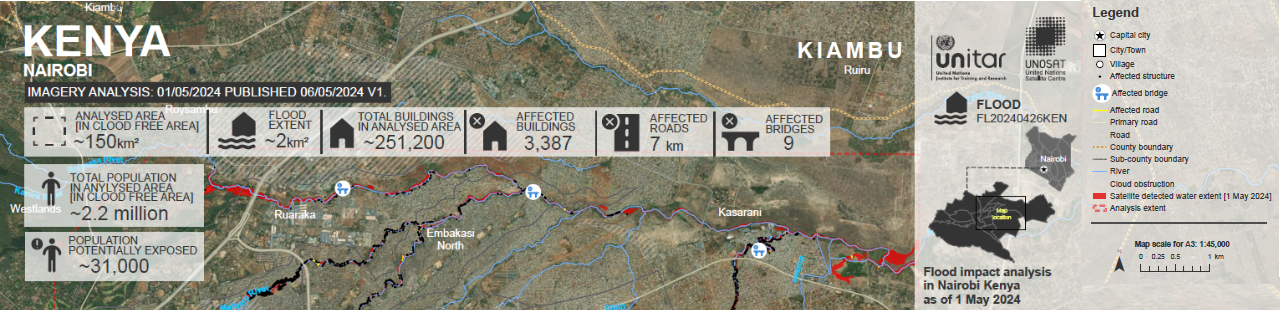
Report source: https://unosat.org/products/3834

Being able to rapidly produce maps of flooded areas in near-real time from satellite imagery is useful for coordinating rescue operations and managing the post-crisis phase.

In this exercise, you will use 10m resolution images from the Sentinel-2 satellite to train machine learning models to map flooded areas.

By the end of the two sessions, you should be able to produce a map of the flooded areas, explain your approach (including your choice of data and models) and critically assess the model's performance. The objective is to analyze where the model predicts flooding and, as much as possible, understand why it may make errors in specific areas.

The Sentinel-2 satellites correspond to a constellation of two satellites (Sentinel- 2A and Sentinel-2B) launched in 2015 and 2017 by the European Space Agency (ESA) as part of the Copernicus program. This program was developed with the aim of providing free, open-source, high-resolution (10 - 20 m) images of land surfaces across the globe with a high temporal revisit time (10 days at the equator with one satellite and five days with two satellites at mid-latitudes). Satellites capture radiation from the visible to the near- and mid-infrared range, with spatial resolutions ranging from 10 m to 60 m in 13 spectral bands.

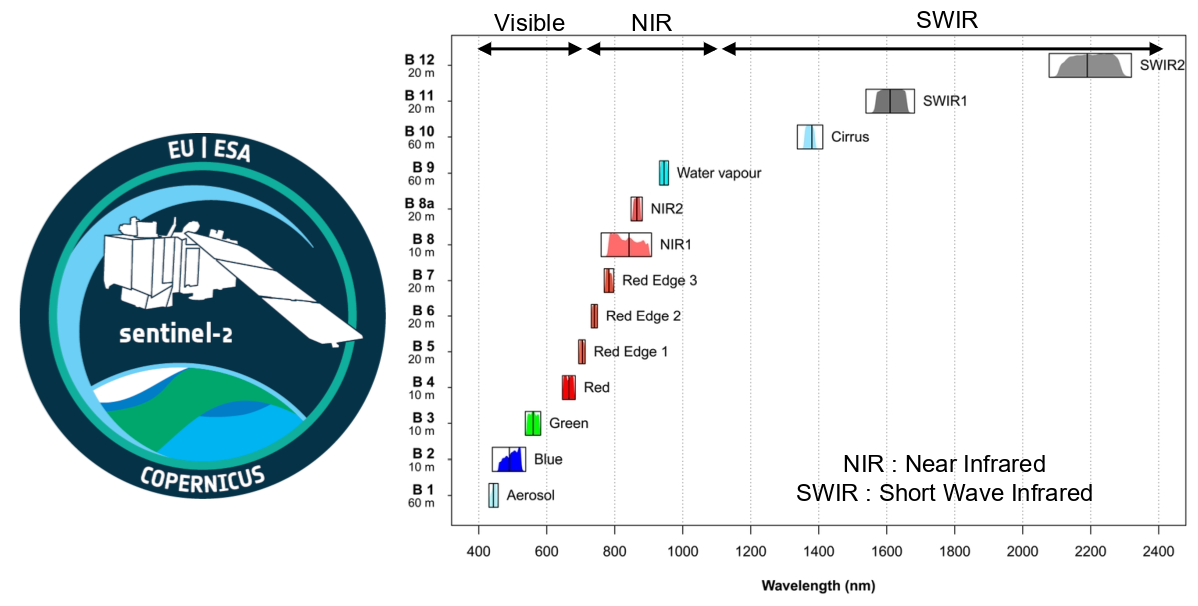

Images can be downloaded from the Copernicus website: https://browser.dataspace.copernicus.eu/

You can also view images from the site in anonymous mode and compare the characteristics of the different bands.

The images provided to users by the Copernicus browser are 110 x 100 km tiles with different levels of pre-processing:
* Level-1C: images measuring reflectance at the top of the atmosphere (TOA), orthorectified and in metric units (UTM);
* Level-2A: surface reflectance images (after atmospheric correction) at the bottom of the atmosphere (BOA), orthorectified and in metric units (UTM).

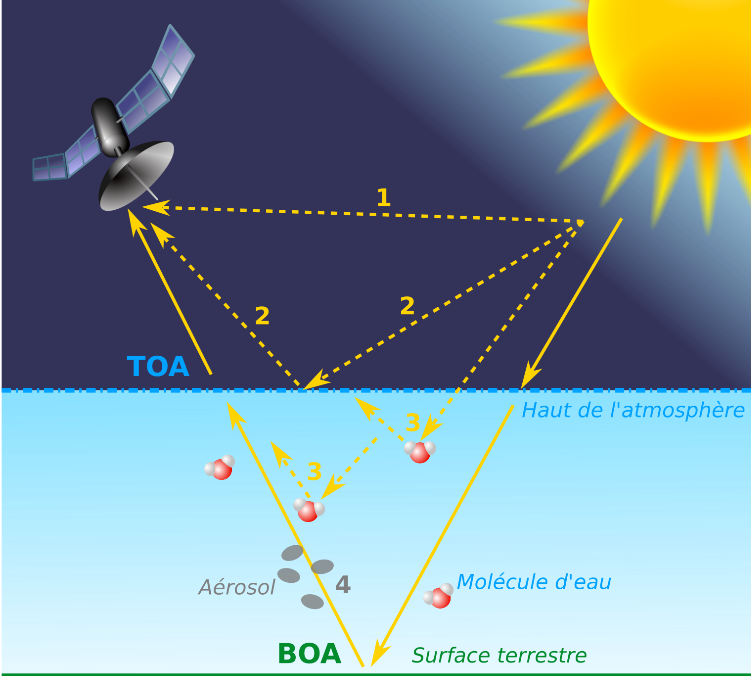

### DATA
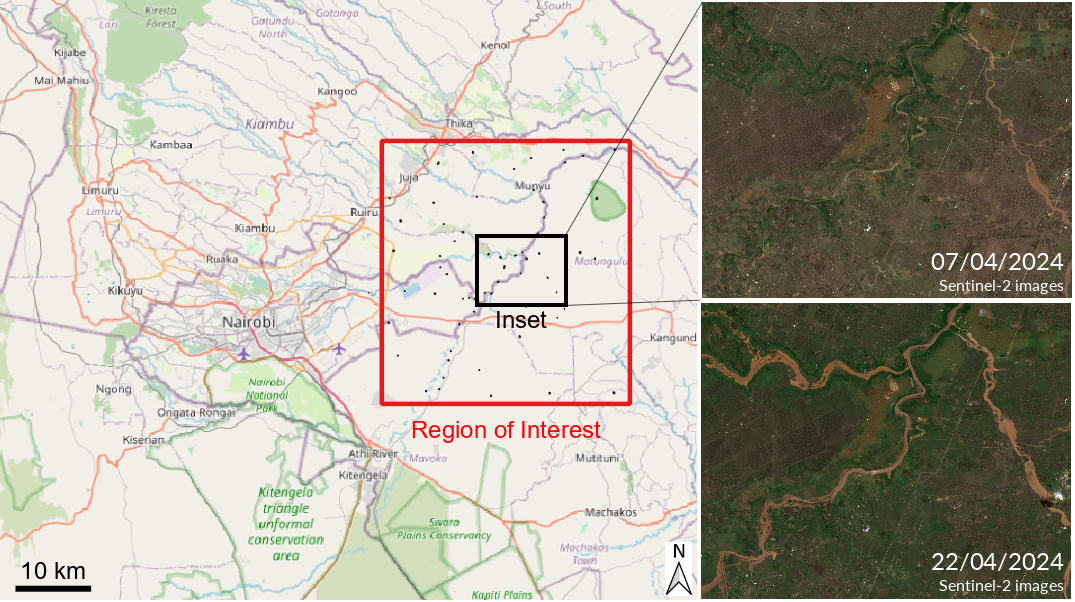

---------------------------------------------------------------------

---------------------------------------------------------------------------
# Beginning of the script: preparation of google drive
---------------------------------------------------------------------------

Installation of rasterio library

In [ ]:
pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 46.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---------------------------------------------------------------------------
# Import package
---------------------------------------------------------------------------

In [ ]:
import numpy as np # Import the numpy library for numerical operations
import rasterio as rio # Import the rasterio library for raster manipulation
import matplotlib.pyplot as plt # Import matplotlib for plotting images
import shapefile
import shapely.geometry as spg
from shapely.geometry import shape as shapely_shape
from rasterio.transform import from_origin
from rasterio.features import geometry_mask
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from rasterio.features import rasterize
from shapely.ops import unary_union
import os

---------------------------------------------------------------------------
# Download data and preprocess
---------------------------------------------------------------------------

In [ ]:

!cp /content/drive/My\ Drive/EASY-ML.zip /content/
!unzip /content/EASY-ML.zip -d /content/

Archive:  /content/EASY-ML.zip
  inflating: /content/EASY-ML_Flood_Detection/Raw_images/IMG_DATA_22_04_2024.zip  
  inflating: /content/EASY-ML_Flood_Detection/Shapefile/testing_data_Nairobi_flood.shp  
  inflating: /content/EASY-ML_Flood_Detection/Shapefile/testing_data_Nairobi_flood.cpg  
  inflating: /content/EASY-ML_Flood_Detection/Shapefile/training_data_Nairobi_flood.shx  
  inflating: /content/EASY-ML_Flood_Detection/Shapefile/ROI_Nairobi_flood.prj  
  inflating: /content/EASY-ML_Flood_Detection/Shapefile/training_data_Nairobi_flood.prj  
  inflating: /content/EASY-ML_Flood_Detection/Shapefile/testing_data_Nairobi_flood.shx  
  inflating: /content/EASY-ML_Flood_Detection/Shapefile/ROI_Nairobi_flood.dbf  
  inflating: /content/EASY-ML_Flood_Detection/Shapefile/training_data_Nairobi_flood.shp  
  inflating: /content/EASY-ML_Flood_Detection/Shapefile/testing_data_Nairobi_flood.prj  
  inflating: /content/EASY-ML_Flood_Detection/Shapefile/testing_data_Nairobi_flood.dbf  
  inflating

In [ ]:
def resampled_raster(src_path, dst_path, resolution=10):
    """
    Resample a raster from 20m resolution to a target resolution (default is 10m).

    This function is designed for Sentinel-2 bands that are originally at 20m resolution
    (e.g., B05, B06, B07, B8A, B11, B12), and resamples them to match the 10m resolution bands.

    Parameters:
        src_path (str): Path to the input raster file (20m resolution).
        dst_path (str): Path to save the resampled output raster (10m resolution).
        resolution (int): Target spatial resolution (default: 10 meters).

    Returns:
        data (ndarray): Resampled image data as a NumPy array.
    """

    # Open the source raster file for reading
    with rio.open(src_path) as src:
        # Calculate the upscale factor (e.g., 20 / 10 = 2)
        upscale_factor = int(src.res[0] / resolution)

        # Resample the image data using bilinear interpolation
        # The new shape is computed by multiplying original height and width by the upscale factor
        data = src.read(
            out_shape=(
                src.count,  # number of bands
                int(src.height * upscale_factor),  # new height
                int(src.width * upscale_factor)    # new width
            ),
            resampling=rio.enums.Resampling.bilinear  # bilinear resampling method
        )

        # Adjust the spatial transform to reflect the new resolution and dimensions
        transform = src.transform * src.transform.scale(
            (src.width / data.shape[-1]),   # scale factor in X direction
            (src.height / data.shape[-2])   # scale factor in Y direction
        )

        # Copy the original metadata profile and update with new shape and transform
        profile = src.profile
        profile.update({
            'height': data.shape[1],     # updated height
            'width': data.shape[2],      # updated width
            'transform': transform       # updated geotransform
        })

        # Write the resampled data to the output file
        with rio.open(dst_path, 'w', **profile) as dst:
            dst.write(data)

    # Print confirmation message
    print(src_path + " ---> resampled")

    # Return the resampled data as a NumPy array
    return data

In [ ]:
# DEFINITION OF FILES PATH

dataset_folder = "/content/EASY-ML_Flood_Detection/Input_data"
process_folder = "/content/EASY-ML_Flood_Detection/Input_data_process"

# Check if folder exists
if not os.path.exists(dataset_folder):
    raise FileNotFoundError(f"Folder '{dataset_folder}' not found.")
os.makedirs(process_folder, exist_ok=True)

file_paths = [dataset_folder + "/ROI_B02_10m.jp2",
              dataset_folder + "/ROI_B03_10m.jp2",
              dataset_folder + "/ROI_B04_10m.jp2",
              dataset_folder + "/ROI_B05_20m.jp2",
              dataset_folder + "/ROI_B06_20m.jp2",
              dataset_folder + "/ROI_B07_20m.jp2",
              dataset_folder + "/ROI_B08_10m.jp2",
              dataset_folder + "/ROI_B8A_20m.jp2",
              dataset_folder + "/ROI_B11_20m.jp2",
              dataset_folder + "/ROI_B12_20m.jp2"]

In [ ]:
# LOAD DATA AND RESAMPLE 20M RESOLUTION BANDS TO 10M RESOLUTION
stack = []
for band in file_paths :
    # define path
    input_path = f"{dataset_folder}/ROI_{band[-11:]}"
    output_path = f"{process_folder}/ROI_{band[-11:-8]}_10m.jp2"

    print(input_path)
    print(output_path)
    # Read raster
    with rio.open(band) as src:
        roi_profile = src.meta.copy()
        roi_array = src.read()

    # Resample 20 m to 10 m
    if roi_profile['transform'][0] != 10 :
        roi_array = resampled_raster(input_path, dst_path=output_path)
        roi_array = roi_array[:,1:-1,:]

    print(roi_array.shape)

    stack.append(roi_array[0,1:-1,:])

# All the bands are stack in a 3D array
stacked = np.array(stack)
print("stacked shape:", stacked.shape)


"""
For example, to select band B04, you need to know its position in the stack,
in this case the 3rd layer. So we retrieve only the band's values, as follows:
"""
B04 = stacked[2,:,:]  # 2 instead of 3 because we start counting at 0
print("B04 shape:", B04.shape)

/content/EASY-ML_Flood_Detection/Input_data/ROI_B02_10m.jp2
/content/EASY-ML_Flood_Detection/Input_data_process/ROI_B02_10m.jp2
(1, 3632, 3426)
/content/EASY-ML_Flood_Detection/Input_data/ROI_B03_10m.jp2
/content/EASY-ML_Flood_Detection/Input_data_process/ROI_B03_10m.jp2
(1, 3632, 3426)
/content/EASY-ML_Flood_Detection/Input_data/ROI_B04_10m.jp2
/content/EASY-ML_Flood_Detection/Input_data_process/ROI_B04_10m.jp2
(1, 3632, 3426)
/content/EASY-ML_Flood_Detection/Input_data/ROI_B05_20m.jp2
/content/EASY-ML_Flood_Detection/Input_data_process/ROI_B05_10m.jp2
/content/EASY-ML_Flood_Detection/Input_data/ROI_B05_20m.jp2 ---> resampled
(1, 3632, 3426)
/content/EASY-ML_Flood_Detection/Input_data/ROI_B06_20m.jp2
/content/EASY-ML_Flood_Detection/Input_data_process/ROI_B06_10m.jp2
/content/EASY-ML_Flood_Detection/Input_data/ROI_B06_20m.jp2 ---> resampled
(1, 3632, 3426)
/content/EASY-ML_Flood_Detection/Input_data/ROI_B07_20m.jp2
/content/EASY-ML_Flood_Detection/Input_data_process/ROI_B07_10m.jp2
/c



Since we are talking about machine learning, it is important to do some feature engineering. Classically, for flood detection, this involves calculating indices from the various bands.

The best-known indices are NDVI (Normalized Difference Vegetation Index), NDWI (Normalized Difference Water Index) and NDFI (Normalized Difference Flood Index).

\begin{align}
    NDVI = \frac{B08 - B04}{B08 + B04}
\end{align}
\begin{align}
\end{align}
\begin{align}
    NDMI = \frac{B03 - B08}{B03 + B08}
\end{align}
and
\begin{align}
    NDFI = \frac{B04 - B012}{B04 + B012}
\end{align}


* https://www.mdpi.com/2072-4292/17/5/770
* https://www.sciencedirect.com/science/article/pii/S0098300424002255?via%3Dihub


In [ ]:
# FEATURE ENGINEERING
def calc_indices(stack):
    """
    Calculation of NDVI and MDWI indices
    """
    B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12 = stack # Be careful to have this order in your stack
    ndvi = (B8 - B4) / (B8 + B4 + 1e-6) # Add small value to avoid division by zero

    # Compute others indices here
    ndwi = (B3 - B8) / (B3 + B8 + 1e-6)
    ndfi = (B4 - B12) / (B4 + B12 + 1e-6)
    return np.stack([*stack, ndvi, ndwi,ndfi])

stacked_indices = calc_indices(stacked)

In [ ]:
stacked_indices

array([[[1.14800000e+03, 1.16000000e+03, 1.21300000e+03, ...,
         1.10700000e+03, 1.07400000e+03, 0.00000000e+00],
        [1.16600000e+03, 1.15500000e+03, 1.25300000e+03, ...,
         1.07000000e+03, 1.10400000e+03, 0.00000000e+00],
        [1.16400000e+03, 1.18300000e+03, 1.30200000e+03, ...,
         1.04700000e+03, 1.11800000e+03, 0.00000000e+00],
        ...,
        [1.62800000e+03, 1.61000000e+03, 1.49600000e+03, ...,
         1.18900000e+03, 1.19700000e+03, 0.00000000e+00],
        [1.56000000e+03, 1.52300000e+03, 1.49200000e+03, ...,
         1.08100000e+03, 1.10600000e+03, 0.00000000e+00],
        [1.62400000e+03, 1.57600000e+03, 1.54900000e+03, ...,
         1.12500000e+03, 1.08700000e+03, 0.00000000e+00]],

       [[1.26600000e+03, 1.31000000e+03, 1.43500000e+03, ...,
         1.38200000e+03, 1.32100000e+03, 0.00000000e+00],
        [1.26900000e+03, 1.28100000e+03, 1.44400000e+03, ...,
         1.27300000e+03, 1.34600000e+03, 0.00000000e+00],
        [1.28700000e+03, 

### FEATURE IMPORTANCE

In [ ]:
# Extract feature importances
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Rank features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

# Select top N features (example selecting top 10 features)
top_features = feature_importance_df['Feature'][:10].values
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

#### VISUALIZING INDICES

In [ ]:
# Select the MNDWI layer, which is the last layer after stacking
mndwi_layer = stacked_indices[-1, :, :]

# Visualize the stacked MNDWI using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(mndwi_layer, cmap='viridis') # Using 'viridis' colormap, you can choose others
plt.title('Stacked MNDWI Visualization')
plt.colorbar(label='MNDWI Value')
plt.show()

---------------------------------------------------------------------------
Preparation of training data
---------------------------------------------------------------------------

In order to have the same distribution between the train dataset, test dataset and the entire area (for make the prediction map), we applied the normalization into the stack of bands. Bands are normalized one by one.



In [ ]:
def normalize_stack(stack):
    """
    Normalize each band/layer of a 3D stack independently to [0, 1] range.

    Parameters:
        stack (ndarray): A 3D NumPy array of shape (bands, height, width).

    Returns:
        normalize_stack (ndarray): A 3D array with each band normalized.
    """

    # Create an empty array with the same shape as the input to store normalized data
    normalize_stack = np.zeros_like(stack)

    # Loop through each band (assumed along the first dimension)
    for i in range(stack.shape[0]):
        data = stack[i, :, :]  # Extract the i-th band (2D array)

        min_data = np.min(data)  # Minimum value in the current band
        max_data = np.max(data)  # Maximum value in the current band

        # Normalize the band to [0, 1] using min-max scaling
        data = (data - min_data) / (max_data - min_data)

        # Store the normalized band in the output array
        normalize_stack[i, :, :] = data

    # Return the fully normalized stack
    return normalize_stack

# Apply data normalization
stacked_normalized = normalize_stack(stacked_indices)
full_stack = stacked_normalized

In [ ]:
"""
Functions for extract the pixels value inside small polygones
defined as training area or testing area
"""

def load_roi_geometry(roi_path):
    """
    Load and merge all geometries from a shapefile representing the ROI (Region of Interest).

    Parameters:
        roi_path (str): Path to the ROI shapefile.

    Returns:
        roi_union (shapely.geometry): A single merged geometry (union of all polygons in the shapefile).
    """
    # Read the shapefile using pyshp
    roi_sf = shapefile.Reader(roi_path)

    # Convert each shape in the shapefile to a Shapely polygon
    roi_geoms = [shapely_shape({'type': 'Polygon', 'coordinates': [sh.points]}) for sh in roi_sf.shapes()]

    # Merge all geometries into one (union of all ROIs)
    roi_union = unary_union(roi_geoms)

    return roi_union

def rasterize_shapefile_with_roi(shapefile_path, roi_path, transform, shape, class_field="class", dtype='uint8'):
    """
    Rasterize polygons from a ground-truth shapefile, limited to the region defined in an ROI shapefile.

    Parameters:
        shapefile_path (str): Path to the shapefile containing labeled polygons.
        roi_path (str): Path to the shapefile defining the region of interest (ROI).
        transform (Affine): Affine transform for the output raster.
        shape (tuple): Output raster shape as (height, width).
        class_field (str): Name of the field containing the class labels in the shapefile.
        dtype (str): Data type for the output raster.

    Returns:
        rasterized (ndarray): 2D array where each pixel has the class label from the shapefile.
    """
    # Read the ground truth shapefile
    sf = shapefile.Reader(shapefile_path)
    shapes = sf.shapes()
    records = sf.records()

    # Extract the list of field names (excluding deletion flag)
    fields = [f[0] for f in sf.fields[1:]]
    class_index = fields.index(class_field)  # Get index of class field

    # Load and merge all geometries from the ROI shapefile
    roi_geom = load_roi_geometry(roi_path)

    geometries = []
    for shp, rec in zip(shapes, records):
        # Convert the shape to a Shapely polygon
        geom = shapely_shape({'type': 'Polygon', 'coordinates': [shp.points]})

        # Clip the geometry to the ROI (intersection)
        geom = geom.intersection(roi_geom)

        # Only keep valid, non-empty geometries
        if not geom.is_empty:
            # Pair the clipped geometry with its class label
            geometries.append((geom, rec[class_index]))

    # Rasterize the geometries to a 2D array
    rasterized = rasterize(
        geometries,
        out_shape=shape,
        transform=transform,
        fill=2,             # Fill value for pixels outside any shape (e.g., nodata)
        all_touched=False,  # Only rasterize pixels whose center is within the geometry
        dtype=dtype
    )

    return rasterized

def extract_pixels_by_mask(stacked_indices, ground_truth, target_label=1):
    """
    Extract pixel vectors (per band) from a 3D image stack where the ground truth equals a given label.

    Parameters:
        stacked_indices (ndarray): 3D array of shape (bands, height, width).
        ground_truth (ndarray): 2D label image of shape (height, width).
        target_label (int): The label value to extract (e.g., 1 for "flooded").

    Returns:
        X (ndarray): 2D array of shape (N_pixels, N_bands), pixel features.
        y (ndarray): 1D array of shape (N_pixels,), containing the label for each pixel.
    """
    # Create a boolean mask where the label equals the target value
    mask = ground_truth == target_label  # shape: (height, width)

    # Get image dimensions
    bands, height, width = stacked_indices.shape

    # Count the number of selected pixels
    n_pixels = np.count_nonzero(mask)

    # Initialize an array to store feature vectors (pixels x bands)
    X = np.zeros((n_pixels, bands), dtype=stacked_indices.dtype)

    # Loop over each band and extract the pixel values using the mask
    for b in range(bands):
        band_data = stacked_indices[b]
        X[:, b] = band_data[mask]  # Apply 2D mask to each band

    # Create the label array (all entries = target_label)
    y = np.full((n_pixels,), target_label, dtype=np.uint8)

    return X, y

In [ ]:
### EXTRACTION TRAIN AND TEST DATASET


### Define file paths for shapefiles and images

# Folder containing shapefiles (training, testing, ROI)
path_folder = "/content/EASY-ML_Flood_Detection/Shapefile/"

# Path to training and testing polygon shapefiles
training_path = path_folder + "training_data_Nairobi_flood.shp"
testing_path = path_folder + "testing_data_Nairobi_flood.shp"

# Path to the ROI shapefile
roi_path = path_folder + "ROI_Nairobi_flood.shp"

# Folder containing input Sentinel-2 images
images_folder = "/content/EASY-ML_Flood_Detection/Input_data/"

# Path to a reference image (used to get shape, transform, CRS)
path_images = images_folder + "ROI_B02_10m.jp2"


### Read the reference image to get spatial information
with rio.open(path_images) as src:
    transform = src.transform   # Affine transform of the image
    crs = src.crs               # Coordinate reference system
    shape = (src.height, src.width)  # Image dimensions (height, width)


### Rasterize shapefiles (convert polygons to raster labels)

# Rasterize the training polygons using the ROI (label map)
GT_train = rasterize_shapefile_with_roi(
    shapefile_path=training_path,
    roi_path=roi_path,
    transform=transform,
    shape=shape,
    class_field="class"       # Name of the class label field in the shapefile
)

# Rasterize the testing polygons using the ROI
GT_test = rasterize_shapefile_with_roi(
    shapefile_path=testing_path,
    roi_path=roi_path,
    transform=transform,
    shape=shape,
    class_field="class"
)


# Extract pixel values and labels for training and testing datasets

# Remove the first and last row caused due to artifacts
GT_train = GT_train[1:-1, :]

# Extract positive (label = 1) and negative (label = 0) samples
X_train_pos, y_train_pos = extract_pixels_by_mask(full_stack, GT_train, target_label=1)
X_train_neg, y_train_neg = extract_pixels_by_mask(full_stack, GT_train, target_label=0)

# Combine positive and negative samples for training
X_train = np.vstack((X_train_pos, X_train_neg))
y_train = np.hstack((y_train_pos, y_train_neg))

# Do the same for the test data
GT_test = GT_test[1:-1, :]
X_test_pos, y_test_pos = extract_pixels_by_mask(full_stack, GT_test, target_label=1)
X_test_neg, y_test_neg = extract_pixels_by_mask(full_stack, GT_test, target_label=0)
X_test = np.vstack((X_test_pos, X_test_neg))
y_test = np.hstack((y_test_pos, y_test_neg))


### Shuffle training and testing sets to avoid label order bias
X_train, y_train = shuffle(X_train, y_train)
X_test, y_test = shuffle(X_test, y_test)

In [ ]:
### EXPLORATION OF THE DATASET

# Dimensions: (number of samples, number of features)
print(X_train.shape)
print(X_test.shape)

# Number of positive sample (flooded area)
pos_indices = np.where(y_train == 1)[0]
n_pos = len(pos_indices)
print(n_pos)

(10443, 13)
(3495, 13)
3766


---------------------------------------------------------------------------
Training and evaluation
---------------------------------------------------------------------------


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import os
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

RANDOM FOREST MODEL BUILDING

In [ ]:
# Your code here
random.seed(42)
# Define a function to train a Random Forest classifier
def train_random_forest(X_train, y_train):
    rf_classifier = RandomForestClassifier(n_estimators=1000, criterion='gini', max_depth=7)
    rf_classifier.fit(X_train, y_train)
    return rf_classifier

In [ ]:
# Train Random Forest classifiers
random_fr = train_random_forest(X_train, y_train)


In [ ]:
predictions = random_fr.predict(X_test)

accuracy_rf = accuracy_score(y_test, predictions)



In [ ]:
accuracy_rf

### CNN MODEL

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8149 - loss: 0.3560 - val_accuracy: 0.9895 - val_loss: 0.0311
Epoch 2/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9875 - loss: 0.0388 - val_accuracy: 0.9909 - val_loss: 0.0209
Epoch 3/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9905 - loss: 0.0270 - val_accuracy: 0.9995 - val_loss: 0.0077
Epoch 4/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9940 - loss: 0.0171 - val_accuracy: 0.9966 - val_loss: 0.0076
Epoch 5/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9983 - loss: 0.0074 - val_accuracy: 0.9995 - val_loss: 0.0025
Epoch 6/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9965 - loss: 0.0108 - val_accuracy: 0.9986 - val_loss: 0.0061
Epoch 7/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9984 - loss: 0.0063 - val_accuracy: 0.9971 - val_loss: 0.0066
Epoch 8/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9961 - loss: 0.0097 - val_accuracy: 0.9995 - val

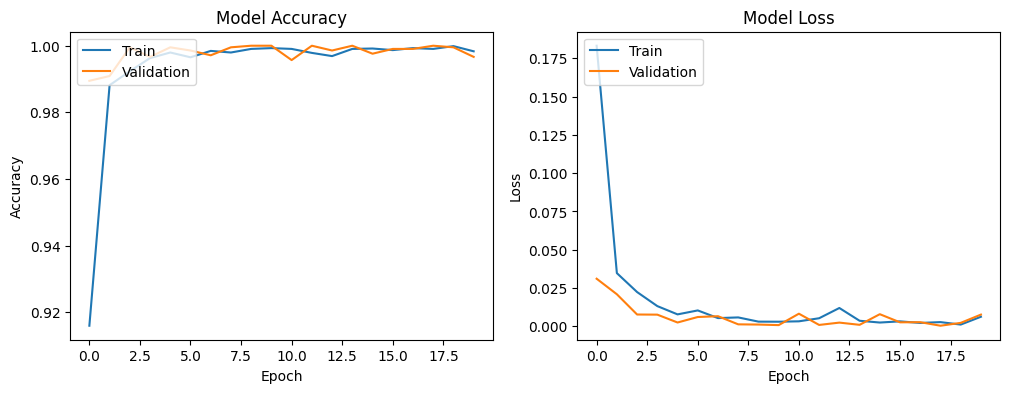

In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Scale the data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape data for CNN (samples, timesteps, features)
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Convert labels to one-hot encoding
y_train_cnn = to_categorical(y_train, num_classes=2)
y_test_cnn = to_categorical(y_test, num_classes=2)

# Build the 1D CNN model
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_reshaped.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax')) # 2 classes: flooded and non-flooded

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_reshaped, y_train_cnn, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy_cnn = model.evaluate(X_test_reshaped, y_test_cnn, verbose=0)

print(f'CNN Test Accuracy: {accuracy_cnn}')

# Make predictions
cnn_predictions_prob = model.predict(X_test_reshaped)
cnn_predictions = np.argmax(cnn_predictions_prob, axis=1)

# Classification Report
print(classification_report(y_test, cnn_predictions))

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()



### SUPPORT VECTOR MACHINE LEARNING

In [ ]:
# Defining the parameters grid for GridSearchCV
param_grid={'C':[0.1,1,10,100,1000]}

# Creating a support vector classifier
svc=LinearSVC()

# Creating a model using GridSearchCV with the parameters grid
model=GridSearchCV(svc,param_grid)

In [ ]:
# Training the model using the training data
model.fit(X_train,y_train)

GridSearchCV(estimator=LinearSVC(), param_grid={'C': [0.1, 1, 10, 100, 1000]})

In [ ]:
# Testing the model using the testing data
y_pred = model.predict(X_test)

# Calculating the accuracy of the model
accuracy_SVM = accuracy_score(y_pred, y_test)



In [ ]:
accuracy_SVM

0.8603719599427754

### KNN

In [ ]:
K = []
training = []
test = []
scores = {}


In [ ]:
for k in range(2, 21):
    clf = KNeighborsClassifier(n_neighbors = k)
    clf.fit(X_train, y_train)

    training_score = clf.score(X_train, y_train)
    test_score = clf.score(X_test, y_test)
    K.append(k)

    training.append(training_score)
    test.append(test_score)
    scores[k] = [training_score, test_score]
    # Testing the model using the testing data
y_pred = model.predict(X_test)

# Calculating the accuracy of the model
accuracy_KNN = accuracy_score(y_pred, y_test)


---------------------------------------------------------------------------
# Creation of a flooded area
---------------------------------------------------------------------------


Finally, post-processing is common, i.e. filtering predictions with morphological operators such as erosion (a), dilation (b), opening (c) and closing (d). Here are the two most interesting for our task:

* Morphological opening: erosion followed by dilation. In principle, we separate objects that are connected by a structure smaller than the structuring element (hence the word “opening”). Since erosion is upstream, we also remove all objects smaller than the structuring element.
* Morphological closure: dilation followed by erosion. Here, objects with “voids” smaller than the structuring element are reconstructed. Upstream dilation also fills small gaps in the image.

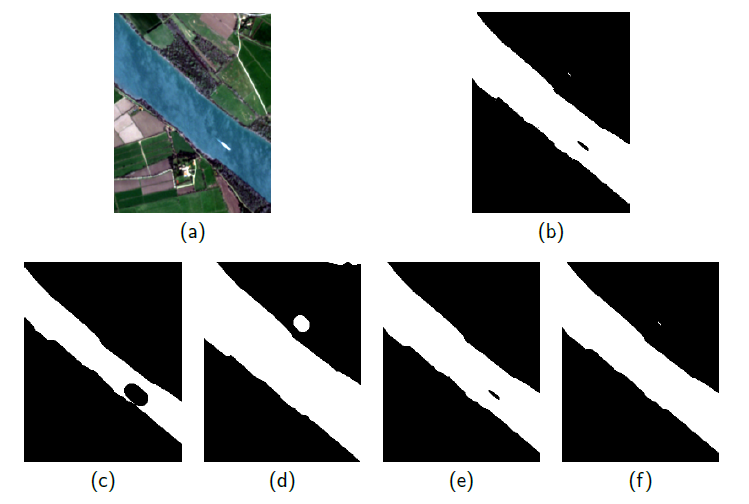

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from skimage.morphology import opening, closing, disk, rectangle, square
from tqdm import tqdm

# ----------------------------------------------------------
# Function to create a pixel-wise prediction map from a model
# ----------------------------------------------------------
def create_prediction_map(normalize_stack, trained_model):
    """
    Applies a trained machine learning model to a normalized image stack
    to create a pixel-wise classification map.

    Parameters:
        normalize_stack (np.ndarray): 3D array of shape (bands, height, width),
                                      representing the normalized image stack.
        trained_model: Trained classifier (e.g., RandomForest) with a `.predict()` method.

    Returns:
        prediction_map (np.ndarray): 2D array (height x width) of predicted class labels.
    """
    # Get dimensions from input stack
    n_bands, height, width = normalize_stack.shape

    # Initialize an empty array to store predictions (same size as the image)
    prediction_map = np.zeros((height, width), dtype=np.int32)

    # Loop over each row of the image
    for row in tqdm(range(height), desc="Generating prediction map"):
        # Extract all band values for the current row
        X_row = normalize_stack[:, row, :]  # Shape: (n_bands, width)
        X_row = X_row.T                     # Transpose to shape: (width, n_bands)

        # Predict class for each pixel in the row using the trained model
        y_pred = trained_model.predict(X_row)  # Shape: (width,)

        # Store predictions in the corresponding row of the prediction map
        prediction_map[row, :] = y_pred

    return prediction_map


# ----------------------------------------------------------
# Function to display a prediction map with custom colors and legend
# ----------------------------------------------------------
def display_prediction_map(prediction_map):
    """
    Displays the prediction map using a color-coded plot.

    Parameters:
        prediction_map (np.ndarray): 2D array of predicted class labels.
    """
    label = 'Predicted Class'

    # Define colors for the classes: [Non-Flooded, Flooded]
    colors = ["#f7fbff", "#08306b"]  # Light blue and dark blue

    # Find the unique class labels in the map
    classes = np.unique(prediction_map)
    n_classes = len(classes)

    # Create a colormap with the number of classes
    cmap = ListedColormap(colors[:n_classes])

    # Create boundaries between class values for discrete color mapping
    bounds = np.arange(n_classes + 1) - 0.5
    norm = BoundaryNorm(bounds, cmap.N)

    # Display the prediction map as an image
    plt.figure()
    im = plt.imshow(prediction_map, cmap=cmap, norm=norm)
    plt.title("Flood Prediction Map")

    # Add a colorbar with class labels
    cbar = plt.colorbar(im, ticks=classes)
    cbar.set_label(label, rotation=270, labelpad=15)

    # Set tick labels manually
    class_labels = ['Non-Flooded', 'Flooded']
    cbar.ax.set_yticklabels(class_labels)

    plt.tight_layout()
    plt.show()


# ----------------------------------------------------------
# Function to export a classification map as a GeoTIFF file
# ----------------------------------------------------------
def export_tiff(array, name, origin, res=10, num_crs=32737, no_data=-99999):
    """
    Saves a 2D array (e.g. prediction map) as a GeoTIFF file.

    Parameters:
        array (np.ndarray): 2D array to export (height x width)
        name (str): Path to save the output .tiff file
        origin (tuple): Top-left corner coordinates (X, Y) in map units
        res (int): Pixel size in map units (e.g. meters)
        num_crs (int): EPSG code for the coordinate system (not used here)
        no_data (int or float): Value for NoData pixels in the TIFF
    """
    # Get array dimensions
    dim = array.shape

    # Define geospatial transform (top-left corner + resolution)
    transform = rio.transform.from_origin(origin[0], origin[1], res, res)

    # Open a new TIFF file for writing
    new_array = rio.open(
        name, 'w',
        driver='GTiff',
        height=dim[0],
        width=dim[1],
        count=1,  # Number of bands
        dtype=array.dtype,
        nodata=no_data,
        transform=transform
        # CRS intentionally omitted; can be added with `crs=rio.crs.CRS.from_epsg(num_crs)`
    )

    # Write the data to the file and close it
    new_array.write(array, 1)
    new_array.close()

""" To apply this function do :
origin = src.get_transform()
export_tiff(prediction_map, output_path, (origin[0], origin[3]))
"""

def apply_morphological_filter(image, operation='opening', kernel_size=3, shape='disk'):
    """
    Apply morphological opening or closing using skimage.morphology.

    Parameters:
        image (ndarray): Input binary or grayscale image.
        operation (str): 'opening' or 'closing'.
        kernel_size (int): Size of the structuring element.
        shape (str): Shape of the structuring element: 'disk', 'square', or 'rectangle'.

    Returns:
        filtered_image (ndarray): Image after morphological operation.
    """

    # Choose the structuring element based on the shape
    if shape == 'disk':
        # Create a disk-shaped structuring element
        selem = disk(kernel_size)
    elif shape == 'square':
        # Create a square-shaped structuring element
        selem = square(kernel_size)
    elif shape == 'rectangle':
        # Create a rectangular structuring element (height = width = kernel_size)
        selem = rectangle(kernel_size, kernel_size)
    else:
        raise ValueError("Shape must be 'disk', 'square', or 'rectangle'.")

    # Apply the chosen morphological operation
    if operation == 'opening':
        # Opening removes small objects/noise
        filtered_image = opening(image, selem)
    elif operation == 'closing':
        # Closing fills small holes/gaps
        filtered_image = closing(image, selem)
    else:
        raise ValueError("Operation must be 'opening' or 'closing'.")

    # Return the filtered image
    return filtered_image


Generating prediction map: 100%|██████████| 3630/3630 [12:25<00:00,  4.87it/s]


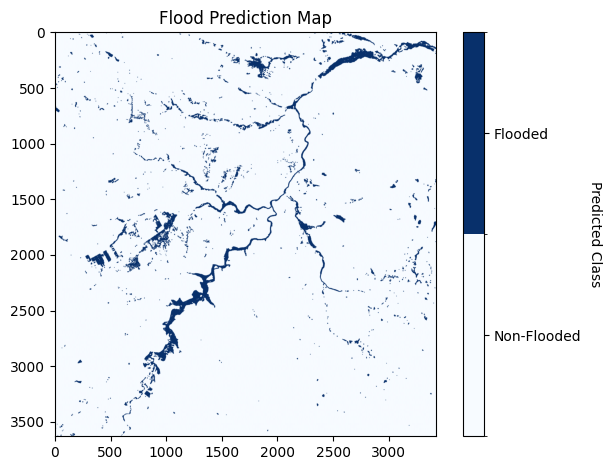

✅ Filtered prediction map exported as filtered_prediction_map.tiff


In [ ]:
import numpy as np
import rasterio as rio
from rasterio.crs import CRS
import matplotlib.pyplot as plt


# STEP 1: Generate prediction map
prediction_map = create_prediction_map(stacked_normalized, random_fr)

# STEP 2: Apply morphological post-processing
filtered_map = apply_morphological_filter(
    prediction_map,
    operation='opening',  # or 'closing'
    kernel_size=3,
    shape='disk'
)

# STEP 3: Visualize the filtered prediction map
display_prediction_map(filtered_map)

# STEP 4: Export to GeoTIFF
# Define the export_tiff function correctly
def export_tiff(array, name, origin, res=10, num_crs=32737, no_data=-99999):
    """
    Saves a 2D array (e.g. prediction map) as a GeoTIFF file.
    """
    dim = array.shape
    transform = rio.transform.from_origin(origin[0], origin[1], res, res)

    with rio.open(
        name, 'w',
        driver='GTiff',
        height=dim[0],
        width=dim[1],
        count=1,
        dtype=array.dtype,
        nodata=no_data,
        transform=transform,
        crs=CRS.from_epsg(num_crs)  # ✅ CRS is now correctly set
    ) as new_array:
        new_array.write(array, 1)

# Load any source raster to get georeferencing information
images_folder = "/content/EASY-ML_Flood_Detection/Input_data/"
path_images = images_folder + "ROI_B02_10m.jp2"

try:
    with rio.open(path_images) as src:
        origin = src.transform
        x_origin = origin[2]
        y_origin = origin[5]
        pixel_size = origin[0]

        export_tiff(
            filtered_map,
            name='filtered_prediction_map.tiff',
            origin=(x_origin, y_origin),
            res=pixel_size,
            num_crs=32737,
            no_data=-99999
        )
    print("✅ Filtered prediction map exported as filtered_prediction_map.tiff")

except Exception as e:
    print(f"❌ Error exporting GeoTIFF: {e}")
